<a href="https://colab.research.google.com/github/putriputrisazkya-code/D121231001_Pemprograman-web/blob/main/quickstarts/Prompting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

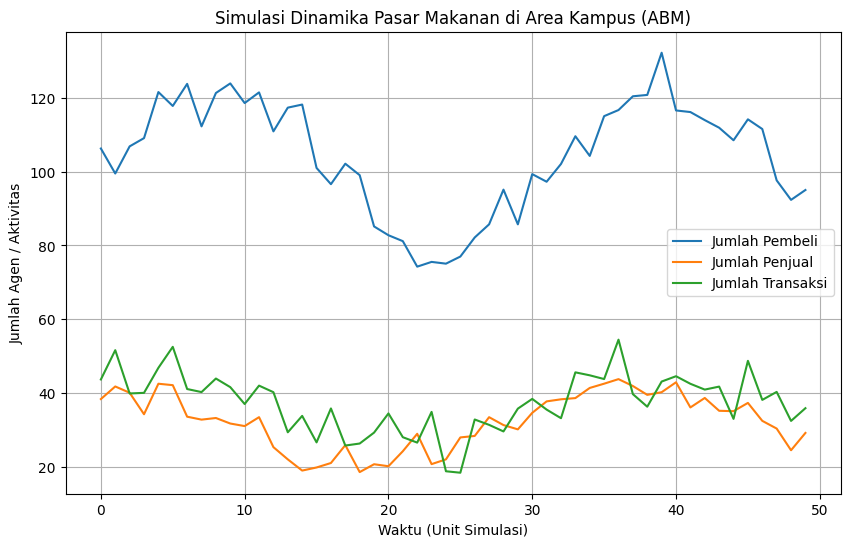

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic simulation data
time = np.arange(0, 50)
buyers = 100 + 20 * np.sin(time / 5) + np.random.normal(0, 5, len(time))
sellers = 30 + 10 * np.cos(time / 6) + np.random.normal(0, 3, len(time))
transactions = buyers * 0.2 + sellers * 0.5 + np.random.normal(0, 5, len(time))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, buyers, label="Jumlah Pembeli")
plt.plot(time, sellers, label="Jumlah Penjual")
plt.plot(time, transactions, label="Jumlah Transaksi")
plt.xlabel("Waktu (Unit Simulasi)")
plt.ylabel("Jumlah Agen / Aktivitas")
plt.title("Simulasi Dinamika Pasar Makanan di Area Kampus (ABM)")
plt.legend()
plt.grid(True)

plt.show()


,Penjual,Total_Pelanggan,Rata2_per_Timestep,Median_per_Timestep,StdDev_per_Timestep,Max_Pelanggan_Timestep,Idle_Timesteps(%),Market_Share(%)
0,Penjual_4,483,9.66,9.0,3.831182,18,0.0,11.52
1,Penjual_8,420,8.40,8.0,3.574285,17,0.0,10.02
2,Penjual_15,389,7.78,8.0,3.085780,15,2.0,9.28
3,Penjual_11,378,7.56,7.5,3.393631,14,0.0,9.02
4,Penjual_2,356,7.12,7.0,3.317486,19,0.0,8.49
5,Penjual_10,333,6.66,6.0,2.661977,14,0.0,7.94
6,Penjual_5,332,6.64,6.0,3.391225,17,0.0,7.92
7,Penjual_9,310,6.20,6.0,2.276768,11,0.0,7.39
8,Penjual_16,283,5.66,6.0,2.745014,11,2.0,6.75
9,Penjual_13,161,3.22,3.0,1.693806,6,4.0,3.84


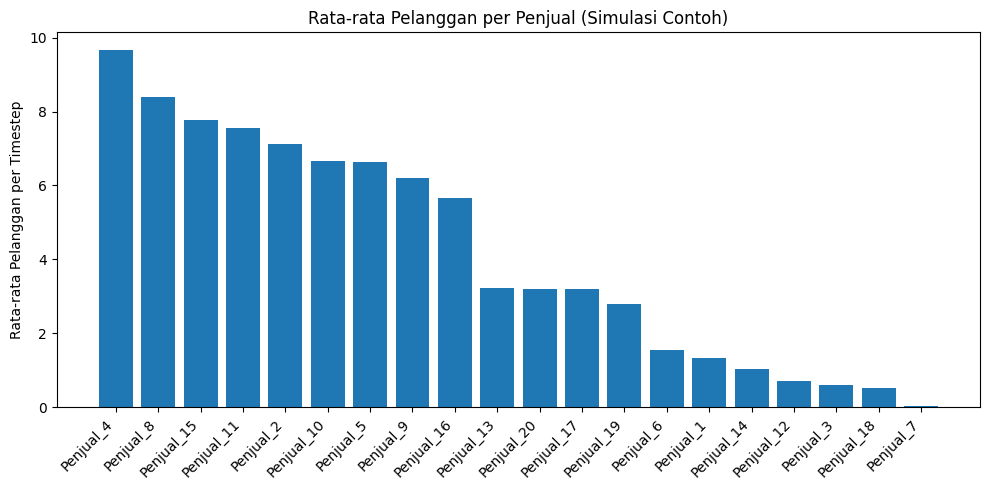

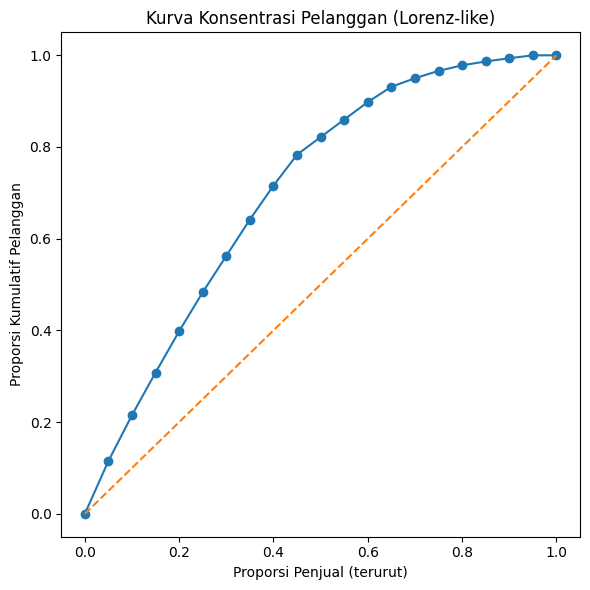

,Value
Total_Pelanggan_Seluruhnya,4193.000
Rata2_Pelanggan_per_Penjual,4.193
Penjual_Top_5_Share(%),48.330
Persentase_Penjual_Idle_Median(%),15.000


In [5]:
# Simulasi contoh dan penghitungan metrik "Jumlah Pelanggan per Penjual"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(42)

# Parameter simulasi
num_sellers = 20
time_steps = 50

# Simulasi sederhana: jumlah pembeli total per timestep berubah mengikuti pola harian
time = np.arange(time_steps)
total_buyers_t = 80 + 30 * np.sin(time / 5) + np.random.normal(0, 6, time_steps)
total_buyers_t = np.clip(total_buyers_t.astype(int), 0, None)

# Set preferensi/atraktifitas awal untuk tiap penjual (lebih besar -> lebih banyak pelanggan menarik)
seller_attractiveness = np.random.rand(num_sellers)
seller_attractiveness = seller_attractiveness / seller_attractiveness.sum()  # normalisasi menjadi proporsi

# Simulasikan alokasi pelanggan ke tiap penjual pada setiap timestep (multinomial sampling)
customers_matrix = np.zeros((time_steps, num_sellers), dtype=int)
for t in range(time_steps):
    customers_matrix[t, :] = np.random.multinomial(total_buyers_t[t], seller_attractiveness)

# Buat DataFrame ringkasan per penjual
sellers = [f"Penjual_{i+1}" for i in range(num_sellers)]
df = pd.DataFrame(customers_matrix, columns=sellers)
summary = pd.DataFrame(index=sellers)
summary["Total_Pelanggan"] = df.sum(axis=0)
summary["Rata2_per_Timestep"] = df.mean(axis=0)
summary["Median_per_Timestep"] = df.median(axis=0)
summary["StdDev_per_Timestep"] = df.std(axis=0)
summary["Max_Pelanggan_Timestep"] = df.max(axis=0)
summary["Idle_Timesteps(%)"] = (df.eq(0).sum(axis=0) / time_steps * 100).round(2)
summary["Market_Share(%)"] = (summary["Total_Pelanggan"] / summary["Total_Pelanggan"].sum() * 100).round(2)

# Urutkan berdasarkan Total_Pelanggan menurun
summary = summary.sort_values(by="Total_Pelanggan", ascending=False)

# Tampilkan tabel ringkasan ke user
display(summary.reset_index().rename(columns={"index":"Penjual"}))

# Visualisasi 1: Bar chart rata-rata pelanggan per penjual
plt.figure(figsize=(10,5))
plt.bar(summary.index, summary["Rata2_per_Timestep"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rata-rata Pelanggan per Timestep")
plt.title("Rata-rata Pelanggan per Penjual (Simulasi Contoh)")
plt.tight_layout()
plt.show()

# Visualisasi 2: Lorenz-like curve (konsentrasi pelanggan)
cumulative = summary["Total_Pelanggan"].cumsum() / summary["Total_Pelanggan"].sum()
cumulative_share = np.insert(cumulative.values, 0, 0)
x = np.linspace(0,1,len(cumulative_share))
plt.figure(figsize=(6,6))
plt.plot(x, cumulative_share, marker='o')
plt.plot([0,1],[0,1], linestyle='--')  # garis kesetaraan
plt.xlabel("Proporsi Penjual (terurut)")
plt.ylabel("Proporsi Kumulatif Pelanggan")
plt.title("Kurva Konsentrasi Pelanggan (Lorenz-like)")
plt.tight_layout()
plt.show()

# Selain tabel dan grafik, tampilkan beberapa metrik ringkas pasar
market_totals = {
    "Total_Pelanggan_Seluruhnya": int(summary["Total_Pelanggan"].sum()),
    "Rata2_Pelanggan_per_Penjual": float(summary["Rata2_per_Timestep"].mean()),
    "Penjual_Top_5_Share(%)": float(summary.head(5)["Market_Share(%)"].sum()),
    "Persentase_Penjual_Idle_Median(%)": float((summary["Idle_Timesteps(%)"]>50).mean()*100)
}
market_totals_df = pd.DataFrame.from_dict(market_totals, orient='index', columns=['Value'])
display(market_totals_df)